In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv("dataset/save_2026-01-25_12-37-14-435_cel_hit.csv")

In [5]:
df.head(5)

,gyro_x,gyro_y,gyro_z,accel_x,accel_y,accel_z,mag_x,mag_y,mag_z,ahrs_x,ahrs_y,ahrs_z,ahrs_w,datetime,gesture
0,-0.002819,-0.037297,-0.031183,-0.636,-8.904,-4.342,47.099998,19.740000,-31.679998,0.397476,-0.472084,0.722889,-0.310775,2026-01-25 12:37:12.699,False
1,-0.002819,-0.037297,-0.031183,-0.636,-8.904,-4.342,46.799999,19.439999,-31.379999,0.397878,-0.472252,0.722540,-0.310816,2026-01-25 12:37:12.717,False
2,-0.009000,-0.046267,-0.030696,-0.714,-8.982,-4.420,46.799999,19.439999,-31.379999,0.398346,-0.472437,0.722136,-0.310876,2026-01-25 12:37:12.734,False
3,-0.009000,-0.046267,-0.030696,-0.714,-8.982,-4.420,46.799999,19.379999,-31.679998,0.398814,-0.472620,0.721732,-0.310936,2026-01-25 12:37:12.751,False
4,-0.009000,-0.046267,-0.030696,-0.714,-8.982,-4.420,46.439999,19.680000,-31.740000,0.399282,-0.472801,0.721327,-0.310999,2026-01-25 12:37:12.767,False


In [6]:
df_gyro = df.filter(regex=r'^accel_y')

In [7]:
df_gyro.describe()

,accel_y
count,4370.000000
mean,-7.928134
std,15.733205
min,-38.560001
25%,-17.534000
50%,-9.610000
75%,-2.157000
max,37.462002


In [8]:
len(df_gyro)

4370

In [9]:
data = df_gyro.values
magnitude = data

In [10]:
magnitude = magnitude.flatten()

In [11]:
magnitude.shape

(4370,)

In [12]:
# Simulate or load accelerometer data (x, y, z)
# For example, load from a CSV file:
# data = np.loadtxt('accelerometer_data.csv', delimiter=',')
# x, y, z = data[:, 0], data[:, 1], data[:, 2]

In [13]:
# Simulate some data for demo
# t = np.linspace(0, 10, 1000)
# x = np.sin(t * 5) + np.random.normal(0, 0.1, 1000)
# y = np.cos(t * 5) + np.random.normal(0, 0.1, 1000)
# z = np.sin(t * 5) + np.random.normal(0, 0.1, 1000)

# Calculate magnitude
# magnitude = np.sqrt(x**2 + y**2 + z**2)

In [14]:
# Simple peak detection
# threshold = 36.0  # Adjust based on your data
# peaks = []
# for i in range(0, len(magnitude)-1):
#     if magnitude[i] > threshold and magnitude[i] >= magnitude[i-1] and magnitude[i] >= magnitude[i+1]:
#         peaks.append(i)

In [15]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(magnitude, height=1.2, distance=10)  # Adjust height and distance

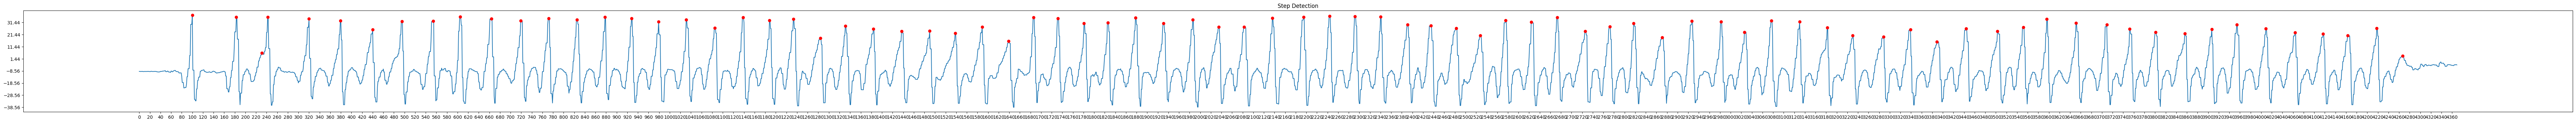

Detected 82 steps


In [16]:
# Plot
plt.figure(figsize=(100, 4))
plt.plot(magnitude)
plt.plot(peaks, magnitude[peaks], 'ro')
plt.xticks(np.arange(0, len(magnitude)-1, 20))
plt.yticks(np.arange(min(magnitude), max(magnitude), 10))
plt.title('Step Detection')
plt.show()

print(f"Detected {len(peaks)} steps")
